# Comparing Official GEM Data with Satellite Observations in Focus Villages

In this notebook, we focus on a selection of villages to quickly compare the official GEM dataset with satellite-derived data. The goal is to see how the official sources match what can be observed from satellite imagery, providing a rapid cross-check of reported vs observed PV installations.

## Setup

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import folium
from IPython.display import display

In [38]:
gem = gpd.read_file("../../data/data_processed/GEM_villages.geojson")
satellite = gpd.read_file("../../data/data_processed/ChinaPV_2010_2022.geojson")

## Overview

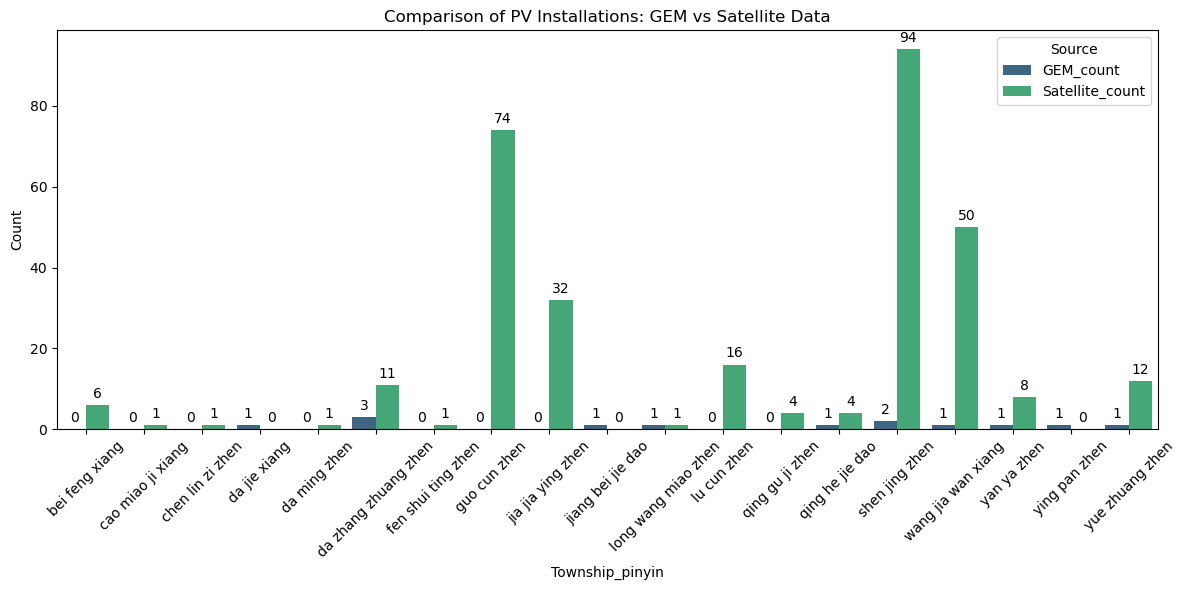

In [39]:
# Example: assume you already have joined_gem and joined_satellite with Township_pinyin column
gem_counts = gem.groupby("Township_pinyin").size().reset_index(name="GEM_count")
sat_counts = satellite.groupby("Township_pinyin").size().reset_index(name="Satellite_count")

# Merge the two counts for comparison
comparison = pd.merge(gem_counts, sat_counts, on="Township_pinyin", how="outer").fillna(0)

# Melt for easier plotting
comparison_melted = comparison.melt(id_vars="Township_pinyin", 
                                    value_vars=["GEM_count", "Satellite_count"], 
                                    var_name="Source", value_name="Count")

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=comparison_melted,
    x="Township_pinyin",
    y="Count",
    hue="Source",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.title("Comparison of PV Installations: GEM vs Satellite Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In general, the satellite imagery dataset appears to be more complete than GEM.
With the exception of only three cases, the number of solar PV installations identified from satellite data is consistently higher (sometimes much higher) than what is reported in GEM.

Let's verify whether the installations captured in both datasets are indeed the same or if the two datasets are rather complementary.

## Visual validation 

In [35]:
township_geom = gpd.read_file("../satellite_image/villages_geom.geojson")

In [37]:
for township, group in township_geom.groupby('Township_pinyin'):
    # Filter points for this township
    gem_points = gem[gem['Township_pinyin'] == township]
    sat_points = satellite[satellite['Township_pinyin'] == township]
    
    # Only proceed if there's at least one point in either dataset
    if len(gem_points) > 0 or len(sat_points) > 0:
        # Create map centered on the township
        centroid_point = group.geometry.representative_point().iloc[0]
        center = [centroid_point.y, centroid_point.x]
        m = folium.Map(location=center, zoom_start=12, tiles='Esri.WorldImagery')
        
        # Add township polygon
        folium.GeoJson(
            group.to_json(),
            style_function=lambda x: {'color': 'orange', 'weight': 2, 'fillOpacity': 0.1},
            tooltip=folium.GeoJsonTooltip(fields=['Township_pinyin'], aliases=['Township:'])
        ).add_to(m)
        
        # Add GEM points
        for _, row in gem_points.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=5,
                color='blue',
                fill=True,
                fill_opacity=0.7,
                popup=f"GEM: {row['Township_pinyin']}"
            ).add_to(m)
        
        # Add Satellite points
        for _, row in sat_points.iterrows():
            folium.CircleMarker(
                location=[row['Lat'], row['Lon']],
                radius=5,
                color='red',
                fill=True,
                fill_opacity=0.7,
                popup=f"Satellite: {row['Township_pinyin']}"
            ).add_to(m)
        
        # Print summary and display map
        print(f"Map for {township}")
        print(f"GEM: {len(gem_points)}, Satellite: {len(sat_points)}")
        display(m)


Map for bei feng xiang
GEM: 0, Satellite: 6


Map for cao miao ji xiang
GEM: 0, Satellite: 1


Map for chen lin zi zhen
GEM: 0, Satellite: 1


Map for da jie xiang
GEM: 6, Satellite: 0


Map for da ming zhen
GEM: 0, Satellite: 1


...

Map for shen jing zhen
GEM: 2, Satellite: 94


Map for wang jia wan xiang
GEM: 1, Satellite: 50


Map for yan ya zhen
GEM: 2, Satellite: 8


Map for ying pan zhen
GEM: 1, Satellite: 0


Map for yue zhuang zhen
GEM: 3, Satellite: 12


Visually the two datasets appear largely consistent rather than complementary. The satellite dataset often shows more points, which is largely because it split large solar plants into multiple geometries, whereas GEM represents the same project as a single entry. In townships where there was only a single GEM point but no visible solar panels in the satellite imagery, these might correspond to planned or not-yet-constructed projects. Overall, the comparison suggests good agreement between the datasets. 